# Heterogeneous Effects and Causal Forests

Alex Ronczewski  
2026-06-20

## Outline

### Prerequisites

-   Notebook 7 of this stream: double machine learning,
    residual-on-residual estimation, and the average effect it produced
-   Comfort with `pandas` and basic Python at the COMET-intermediate
    level

### Learning Outcomes

By the end of this notebook you will be able to:

1.  Define the **conditional average treatment effect (CATE)** and say
    how it differs from the ATE.
2.  Estimate a CATE with **meta-learners**, the S-learner and the
    T-learner.
3.  Explain why a **causal forest** estimates the effect more steadily,
    and fit one.
4.  Visualize how an effect varies across the population.
5.  Use the CATE to **target** a policy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from econml.dml import CausalForestDML

RANDOM_STATE = 42

## 1. From the average to who benefits

Notebook 7 ended with one number: 401(k) eligibility raised net
financial assets by about 8,800 dollars on average. That word “average”
is hiding something, though. An effect of 8,800 dollars on average could
mean every household gains roughly 8,800, or it could mean some
households gain a great deal and others almost nothing, and for policy
that difference matters. If only some households benefit, we’d want to
know which ones.

This is the move from the average treatment effect to the **conditional
average treatment effect (CATE)**, the effect for households with a
given set of characteristics:

$$
\tau(x) = \mathbb{E}\big[\, Y(1) - Y(0) \;\big|\; X = x \,\big].
$$

The ATE is one number for everyone, while the CATE is a function that
gives a different effect for each kind of household. Averaging $\tau(x)$
over all households gives back the ATE, so the CATE refines the average
rather than replacing it.

> **CATE versus ATE**
>
> The **ATE** answers “what is the effect on average?” and returns a
> single number. The **CATE** answers “what is the effect for households
> like this one?” and returns a value that varies with the
> characteristics $X$. The same potential-outcomes and unconfoundedness
> ideas from Notebook 4 are still doing the work; we are now asking for
> the effect at each $x$ instead of pooled over all of them.

We use the same 401(k) data, treatment, and confounders as Notebook 7.

In [2]:
savings = pd.read_csv("datasets/Pension401k.csv")
confounders = ["age", "inc", "educ", "fsize", "marr", "twoearn", "db", "pira", "hown"]
D = savings["e401"].to_numpy().astype(float)
Y = savings["net_tfa"].to_numpy()
X = savings[confounders].to_numpy()

## 2. Meta-learners

The most direct way to estimate a CATE is to predict savings for a
household twice, once as if eligible and once as if not, and subtract.
These recipes are called **meta-learners**, because they build a causal
estimate out of ordinary predictors.

The **T-learner** (“T” for two) fits two separate models: one for the
savings of eligible households as a function of their covariates, one
for the savings of ineligible households. The CATE for any household is
the gap between what the two models predict for it.

In [3]:
mu1 = RandomForestRegressor(n_estimators=300, min_samples_leaf=20,
                            random_state=RANDOM_STATE, n_jobs=-1).fit(X[D == 1], Y[D == 1])
mu0 = RandomForestRegressor(n_estimators=300, min_samples_leaf=20,
                            random_state=RANDOM_STATE, n_jobs=-1).fit(X[D == 0], Y[D == 0])

cate_t = mu1.predict(X) - mu0.predict(X)
print(f"T-learner CATE: mean {cate_t.mean():.2f}, ranging from {cate_t.min():.0f} to {cate_t.max():.0f}")

T-learner CATE: mean 7.43, ranging from -142 to 103

The mean is 7.43 thousand dollars, in the same range as Notebook 7’s
average. There is another meta-learner called the **S-learner** (“S” for
single), which fits one model with eligibility thrown in as just another
feature, then predicts each household with the feature flipped on and
off. In both models we use two predicted outcomes and take the
difference.

### 2.1 Why the T-learner estimate is noisy

Meta-learners are the natural first thing to try. They are simple, they
reuse any predictor you already trust, and they simplify the CATE to
just subtraction. When each treatment group is large and the outcome is
fairly clean, they work well and are often used. The issue is that our
data is difficult.

Look again at the range the T-learner reported, from negative 142 to
positive 103 thousand dollars. We do not believe eligibility swings
savings by that much; the extremes come from the simple method being
used on complex data. The T-learner reads the CATE off the gap between
two models, each fit on its own group, so the estimate inherits the
noise of both. Net financial assets have large tails, a handful of
households hold enormous sums, so each forest is already noisy on its
own, and subtracting one from the other magnifies it.

In [4]:
print(f"T-learner CATE spread (standard deviation): {cate_t.std():.1f}")

T-learner CATE spread (standard deviation): 14.7

A standard deviation of 14.7 around a mean of 7.4 shows us that
magnified noise. The logic of the T-learner is sound and its average is
reliable, close to Notebook 7’s. What suffers is the per-household
detail, and that detail is really what we want a CATE for. The S-learner
has the opposite weakness: by folding eligibility in as just one feature
among many, the single model can lean on it too lightly and flatten the
effect toward zero, hiding the very variation we are after. The two
meta-learners fail in opposite directions, one amplifying noise and the
other muting the signal, and the causal forest is built to avoid both:
it estimates the effect as a single quantity, directly, instead of as
the gap between two separate guesses.

## 3. The causal forest

A causal forest is the random forest of Notebook 3, reframed for a
causal question. Recall what a random forest does: it grows many trees,
each splitting the data into groups of similar households, and predicts
a household’s **outcome** by averaging the outcomes in its group. A
causal forest grows trees the same way, but inside each group it does
something different: it estimates the **treatment effect**, by comparing
eligible and ineligible households within the group. The splits are
chosen to separate households whose effects differ, so the forest goes
looking for the heterogeneity we care about.

To handle confounding it leans on Notebook 7. Inside the forest, savings
and eligibility are first residualized on the covariates, the
residual-on-residual idea from double machine learning, so the effect it
reads within each group is de-confounded. You can think of a causal
forest as double machine learning and a random forest working together.

> **How a causal forest differs from a random forest**
>
> A **random forest** (Notebook 3) splits the data into groups of
> similar units and averages the **outcome** in each: it predicts $Y$. A
> **causal forest** splits into groups of similar units and estimates
> the **treatment effect** in each, after residualizing out the
> confounders the way Notebook 7 did: it predicts $\tau(x)$. It targets
> effect instead of outcome.

Because the CATE is a whole function rather than one number, it needs
everything the ATE needed and a little bit more. Before fitting
anything, we state the conditions under which the forest’s per-household
effects have a causal meaning.

> **Identification conditions for the causal forest**
>
> 1.  **Unconfoundedness (selection on observables), at every $x$.**
>     Conditional on the nine covariates, eligibility must be as good as
>     randomly assigned: $(Y(0), Y(1)) \perp D \mid X$. This is the same
>     untestable assumption as in Notebooks 4 to 7, but it now has to do
>     local work: the CATE at $x$ is identified only if there is no
>     unmeasured confounding among households like $x$. A forest finds
>     heterogeneity in whatever it is given; if what it is given is
>     confounded, it will find heterogeneous bias without any visible
>     errors.
> 2.  **Overlap, at every $x$.** Each kind of household must have both
>     eligible and ineligible members, $0 < P(D = 1 \mid X = x) < 1$,
>     because the forest estimates each local effect by comparing the
>     two groups within a neighbourhood. Regions of the covariate space
>     where nearly everyone is on one side produce CATE estimates that
>     rest on almost no comparisons and should not be trusted.
> 3.  **A random, independent sample.** The consistency and
>     confidence-interval theory for causal forests treats households as
>     i.i.d. draws, with no interference between households and one
>     version of the treatment (SUTVA and consistency), just as always.
> 4.  **Honest trees.** Each tree must not use the same households both
>     to choose its splits and to estimate the effects inside its
>     leaves; the sample is split so one part shapes the tree and the
>     other fills it in. This **honesty** condition plays the role
>     cross-fitting played in Notebook 7, and it is what the Wager-Athey
>     theory needs for the estimates to be consistent and for their
>     confidence intervals to be valid. The `econml` estimator we use
>     below does this by default.
> 5.  **De-confounding through the DML residualization, and a CATE that
>     varies smoothly.** The forest inherits Notebook 7’s requirements
>     for its internal step: the savings and eligibility models must be
>     estimated well enough (with cross-fitting) for the
>     residual-on-residual comparison inside each neighbourhood to be
>     clean. And the theory assumes $\tau(x)$ changes smoothly with $x$,
>     so that households close in covariates have close effects; that is
>     what justifies estimating a household’s effect from its neighbours
>     at all.

Points 1 to 3 are the same statement of unconfoundedness, overlap, and
i.i.d. sampling that every method in this stream has rested on, now
required locally rather than on average. Points 4 and 5 are the
forest-specific conditions that make flexible, data-driven heterogeneity
search compatible with valid inference.

We use the `CausalForestDML` estimator from the `econml` package, which
puts these pieces together for us. We give it a model for savings and a
model for eligibility, the two nuisance predictors from Notebook 7, and
it does the residualizing and the effect-splitting for us.

In [5]:
def make_causal_forest():
    return CausalForestDML(
        model_y=RandomForestRegressor(n_estimators=200, min_samples_leaf=20,
                                      random_state=RANDOM_STATE, n_jobs=-1),
        model_t=RandomForestClassifier(n_estimators=200, min_samples_leaf=20,
                                       random_state=RANDOM_STATE, n_jobs=-1),
        discrete_treatment=True, n_estimators=500, min_samples_leaf=20,
        cv=3, random_state=RANDOM_STATE)

### 3.1 Does it work? Checking on a known result

Before trusting the forest on real data, we first build a world where
the true effect is not constant: it is 1 for households with a low value
of the first covariate and climbs to about 4 for those with a high
value. Then we ask whether the causal forest can find that rising shape.

In [6]:
rng = np.random.default_rng(RANDOM_STATE)
n = 4000
X_sim = rng.normal(0, 1, (n, 5))
true_cate = 1.0 + np.maximum(X_sim[:, 0], 0) * 2          # flat at 1, then rising with the first covariate
prob = 1 / (1 + np.exp(-(0.5 * X_sim[:, 1] - 0.5 * X_sim[:, 2])))
D_sim = (rng.uniform(size=n) < prob).astype(float)        # treatment depends on covariates: confounding
Y_sim = true_cate * D_sim + X_sim[:, 1] + X_sim[:, 2] + rng.normal(0, 1, n)

forest_sim = make_causal_forest().fit(Y_sim, D_sim, X=X_sim)
est_cate = forest_sim.effect(X_sim)
print(f"Correlation between true and estimated CATE: {np.corrcoef(true_cate, est_cate)[0, 1]:.3f}")

Correlation between true and estimated CATE: 0.987

A correlation of 0.987 means the forest’s effect estimates line up
almost perfectly with the truth. The plot shows it: households binned by
the first covariate, the true effect against the estimated.

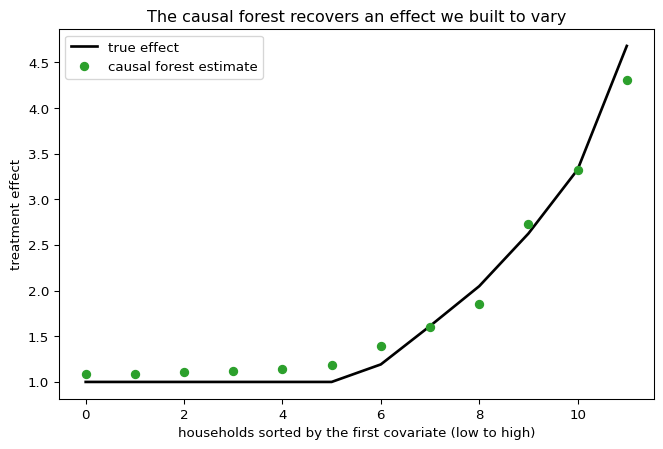

In [7]:
bins = pd.qcut(X_sim[:, 0], 12, labels=False)
true_by_bin = [true_cate[bins == b].mean() for b in range(12)]
est_by_bin = [est_cate[bins == b].mean() for b in range(12)]

plt.figure(figsize=(8, 5))
plt.plot(true_by_bin, color="black", linewidth=2, label="true effect")
plt.plot(est_by_bin, "o", color="tab:green", label="causal forest estimate")
plt.xlabel("households sorted by the first covariate (low to high)")
plt.ylabel("treatment effect")
plt.title("The causal forest recovers an effect we built to vary")
plt.legend()
plt.show()

The estimates sit right on the true curve, flat where we made the effect
flat and rising where we made it rise, so the forest has picked up the
heterogeneity correctly. It worked!

### 3.2 Who benefits from 401(k) Eligibility

Now we turn it on the real question. We fit the causal forest to the
401(k) data and read off each household’s estimated effect.

In [8]:
forest = make_causal_forest().fit(Y, D, X=X)
cate = forest.effect(X)
print(f"Causal forest CATE: mean {cate.mean():.2f}, standard deviation {cate.std():.1f}")
print(f"Share of households with a positive effect: {(cate > 0).mean():.2f}")

Causal forest CATE: mean 7.79, standard deviation 6.5
Share of households with a positive effect: 0.97

The mean is 7.79 thousand dollars, close to Notebook 7’s average of
8.80, which is the consistency we expect: average the CATEs and you get
back the ATE. The new information is in the spread. The standard
deviation is 6.5, far tighter than the T-learner’s 14.7, because the
forest estimates the effect directly instead of differencing two noisy
predictions. And 97% of households have a positive effect, so
eligibility helps almost everyone, but by very different amounts.

Where does the effect come from? We group households by income and
average the estimated effect in each quarter of the income distribution.

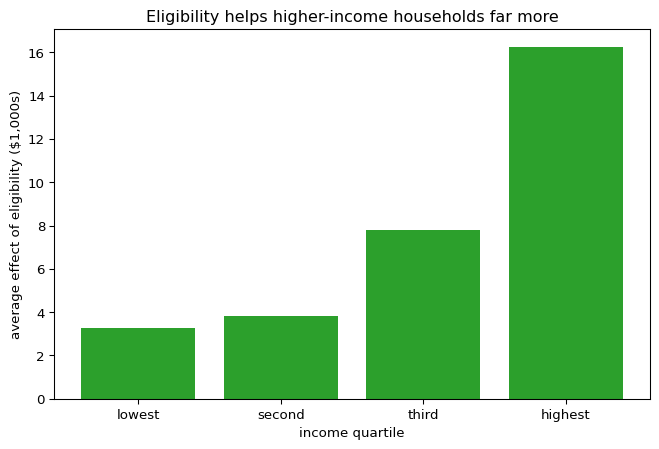

lowest      3.3
second      3.8
third       7.8
highest    16.3

In [9]:
income_quartile = pd.qcut(savings["inc"], 4, labels=["lowest", "second", "third", "highest"])
mean_by_income = pd.Series(cate).groupby(income_quartile.values, observed=True).mean()
mean_by_income = mean_by_income.reindex(["lowest", "second", "third", "highest"])

plt.figure(figsize=(8, 5))
plt.bar(mean_by_income.index, mean_by_income.values, color="tab:green")
plt.ylabel("average effect of eligibility ($1,000s)")
plt.xlabel("income quartile")
plt.title("Eligibility helps higher-income households far more")
plt.show()

print(mean_by_income.round(1).to_string())

The effect climbs steeply with income: about 3.3 thousand dollars for
the lowest-income quarter, rising to 16.3 thousand for the highest. This
fits the economic theory. A household with little spare income cannot
save much into a 401(k) however eligible it is, while a high-income
household can. The distribution of effects below tells the same story: a
bulge of modest effects with a long right tail of larger ones.

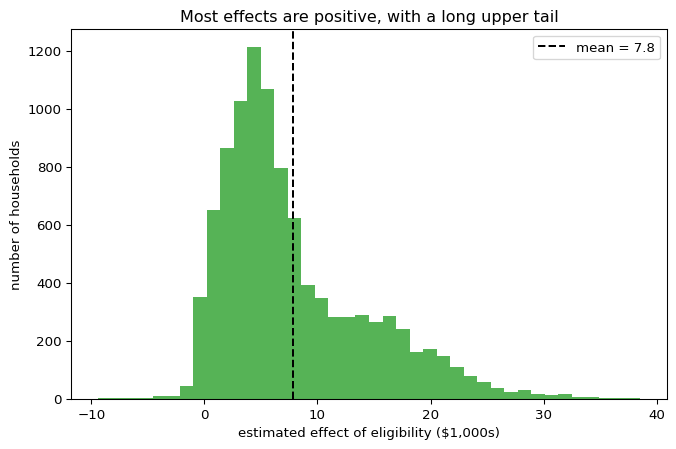

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(np.clip(cate, -10, 40), bins=40, color="tab:green", alpha=0.8)
plt.axvline(cate.mean(), color="black", linestyle="--", label=f"mean = {cate.mean():.1f}")
plt.xlabel("estimated effect of eligibility ($1,000s)")
plt.ylabel("number of households")
plt.title("Most effects are positive, with a long upper tail")
plt.legend()
plt.show()

## 4. Targeting a Policy

Once we know who benefits, we can act on it. Suppose a program could
extend 401(k) eligibility, but only to half the households. Spending
that budget on the half with the largest estimated effects, rather than
spreading it evenly.

In [11]:
high_benefit = cate >= np.median(cate)
print(f"Average effect, households we would target (top half): {cate[high_benefit].mean():.1f}")
print(f"Average effect, households we would skip (bottom half): {cate[~high_benefit].mean():.1f}")

Average effect, households we would target (top half): 12.6
Average effect, households we would skip (bottom half): 3.0

The targeted half has an average effect of 12.6 thousand dollars, more
than four times the 3.0 in the half we would skip. It’s the same policy
on the same budget, but the return is very different depending on who
receives it. This is the practical reason CATEs matter: the average
tells you whether a policy works at all, and the CATE tells you where
the money is best spent.

> **Self-test**
>
> The causal forest’s mean CATE (7.79) is close to the double machine
> learning estimate from Notebook 7 (8.80). Should we expect them to
> agree exactly?
>
> <details>
>
> <summary>
>
> Show / hide answer
>
> </summary>
>
> We should expect them close, though not identical. Both estimate the
> same average effect, so averaging the causal forest’s per-household
> CATEs should land near the Notebook 7 number. They differ a little
> because they use a different framework (a forest that splits on effect
> differences versus a single residual-on-residual regression) and
> slightly different settings, so each has its own unique estimation
> error.
>
> </details>

## 5. The end of the stream

This is the last notebook, so let’s look back at the whole stream. We
started with prediction: Notebooks 1 to 3 built a toolkit for us to use,
k-nearest-neighbours, ridge and lasso, trees and forests, and learned to
differentiate a model that generalizes from one that memorises. Notebook
4 was the main shift, drawing the line between predicting an outcome and
identifying a cause, and naming what it takes to cross it. Then four
causal tools, each paired with a prediction tool aimed at a causal
target: post-double-selection lasso (Notebook 5), propensity weighting
and the doubly-robust estimator (Notebook 6), double machine learning
(Notebook 7), and now the causal forest. Thank you for reading, I hope
this stream has helped to demystify causal machine learning and has
given you all kinds of ideas for projects, further learning or Econ 490.

### 5.1 Where to go next

Everything in this stream rested on one identification strategy:
unconfoundedness, the assumption that we measured every confounder. That
is one road into causal inference, and there are others. Two we pointed
at in Notebook 4 are where to head first.

-   **Instrumental variables with machine learning.** When
    unconfoundedness fails because of an unmeasured confounder, an
    instrument can fix identification: a variable that shifts the
    treatment but affects the outcome only through it. The same
    residualize-and-orthogonalize machinery from Notebook 7 carries
    over, with flexible learners estimating the first stage and the
    controls while the instrument supplies the variation. You may have
    studied IV in Econ 326, 398 or 425 so this is a natural next step.
-   **Difference-in-differences with machine learning.** The
    parallel-trends design combines with flexible learners for the
    controls and for effects that vary across units and over time.

### 5.2 Recommended reading

These are the sources this stream was built from, and I highly recommend
them if you wish to keep learning!

-   Chernozhukov, Hansen, Kallus, Spindler, and Syrgkanis, *Applied
    Causal Inference Powered by ML and AI*
    ([causalml-book.org](https://causalml-book.org/)). The closest match
    to this stream, free online, and the source of the growth and 401(k)
    examples.
-   Facure, *Causal Inference for the Brave and True*
    ([python-causality-handbook](https://matheusfacure.github.io/python-causality-handbook/landing-page.html)).
    A code-first source that covers IV and difference-in-differences in
    depth.
-   Athey and Imbens, *Machine Learning Methods That Economists Should
    Know About*
    ([arxiv.org/pdf/1903.10075](https://arxiv.org/pdf/1903.10075)). A
    survey of the whole field by two of its founders.
-   QuantEcon, *Machine Learning in Economics*
    ([datascience.quantecon.org](https://datascience.quantecon.org/applications/ml_in_economics.html)).
    Applied lecture notes in Python.
-   The `EconML` ([pywhy.org/EconML](https://www.pywhy.org/EconML/)) and
    `DoubleML`
    ([docs.doubleml.org](https://docs.doubleml.org/stable/index.html))
    documentation. The production libraries behind the tools we built by
    hand.
-   UBC ECON 526
    ([ubcecon.github.io/ECON526](https://ubcecon.github.io/ECON526/)).
    The UBC graduate course this stream previews.

### 6 Connections

-   **Back to [Notebook 7](notebook_07_double_machine_learning.qmd):**
    there double machine learning gave one average effect of 401(k)
    eligibility; here the causal forest, built from the same
    residual-on-residual idea and the random forest of Notebook 3, shows
    how that effect varies across households.

### References

-   Athey, S., Tibshirani, J., & Wager, S. (2019). *Generalized random
    forests.* Annals of Statistics, 47(2), 1148-1178.
-   Battocchi, K., Dillon, E., Hei, M., Lewis, G., Oka, P., Oprescu, M.,
    & Syrgkanis, V. (2019). *EconML: A Python package for ML-based
    heterogeneous treatment effects estimation.* The `econml` library.
-   Jacob, D. (2021). *CATE meets ML: The conditional average treatment
    effect and machine learning.* arXiv:2104.09935.
-   Jawadekar, N., Kezios, K., Odden, M. C., Stingone, J. A., Calonico,
    S., Rudolph, K., & Zeki Al Hazzouri, A. (2023). *Practical guide to
    honest causal forests for identifying heterogeneous treatment
    effects.* American Journal of Epidemiology, 192(7), 1155-1165.
-   Kunzel, S. R., Sekhon, J. S., Bickel, P. J., & Yu, B. (2019).
    *Metalearners for estimating heterogeneous treatment effects using
    machine learning.* PNAS, 116(10), 4156-4165. The S-learner,
    T-learner, and X-learner.
-   LOST (Library of Statistical Techniques). (n.d.). *Causal forest.*
    https://lost-stats.github.io/Machine_Learning/causal_forest.html
-   Poterba, J. M., Venti, S. F., & Wise, D. A. (1995). *Do 401(k)
    contributions crowd out other personal saving?* Journal of Public
    Economics, 58(1), 1-32. The eligibility question.
-   Wager, S., & Athey, S. (2018). *Estimation and inference of
    heterogeneous treatment effects using random forests.* Journal of
    the American Statistical Association, 113(523), 1228-1242. The
    causal forest.

------------------------------------------------------------------------